# Plotting Slopes of Extreme Precip Cell Properties 

## Load Libraries

In [1]:
import pandas as pd
import numpy as np
import os
import xarray as xr
import sys

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns



# load tool set
sys.path.append("../tools")
import plotting
import monthly_data_vars_meta
import imports

## Load data

In [2]:
# dir to data
main_directory = '/work/bb1376/user/leonie/NextGEMS_analysis/output'

### Data for different threshold definitions (experiments/variants)

In [3]:
# data => for left figure
#df1 = pd.read_csv(f'{main_directory}/1_deg/5_percent_contribution/aux_output/df_lm_coefficients_boot_all_rel_T_relative_CIspace.csv')
df2 = pd.read_csv(f'{main_directory}/1_deg/10_percent_contribution/aux_output/df_lm_coefficients_boot_all_rel_T_relative_CIspace.csv')
df3 = pd.read_csv( f'{main_directory}/1_deg/30_percent_contribution/aux_output/df_lm_coefficients_boot_all_rel_T_relative_CIspace.csv')
df4 = pd.read_csv( f'{main_directory}/1_deg/500_mm/aux_output/df_lm_coefficients_boot_all_rel_T_relative_CIspace.csv')
df5 = pd.read_csv( f'{main_directory}/1_deg/200_mm/aux_output/df_lm_coefficients_boot_all_rel_T_relative_CIspace.csv')
df6 = pd.read_csv( f'{main_directory}/1_deg/80_mm/aux_output/df_lm_coefficients_boot_all_rel_T_relative_CIspace.csv')
#df7 = pd.read_csv( f'{main_directory}/1_deg/100_mm/aux_output/df_lm_coefficients_boot_all_rel_T_relative_CIspace.csv')
df8 = pd.read_csv( f'{main_directory}/1_deg/50_percent_contribution/aux_output/df_lm_coefficients_boot_all_rel_T_relative_CIspace.csv')
# df9 = pd.read_csv( f'{main_directory}/1_deg/1_percent_contribution/aux_output/df_lm_coefficients_boot_all_rel_T_relative_CIspace.csv')
# df10 = pd.read_csv( f'{main_directory}/1_deg/300_mm/aux_output/df_lm_coefficients_boot_all_rel_T_relative_CIspace.csv')
# df11 = pd.read_csv( f'{main_directory}/1_deg/400_mm/aux_output/df_lm_coefficients_boot_all_rel_T_relative_CIspace.csv')



# variant labels
#df1['variant'] = '95 %' 
df2['variant'] = '90 %'
df3['variant'] = '70 %'
df4['variant'] = '500 mm'
df5['variant'] = '200 mm'
df6['variant'] = '80 mm'
#df7['variant'] = '100 mm'
df8['variant'] = '50 %'
#df9['variant'] = '99 %'
#df10['variant'] = '300 mm'
#df11['variant'] = '400 mm'

# combine
df_all = pd.concat([df2, df3,df4,df5,df6,df8])

# xarray
ds = df_all.set_index(['variant','variable']).to_xarray()

### Data for 10 % contribution 

In [4]:
# data =>  for right figure 
experiment =  "10_percent_contribution" #experiment # from import defs
name_experiment = "90% contribution"

# dir with paths
csv_info= {
    'All': f'{main_directory}/1_deg/{experiment}/aux_output/df_lm_coefficients_boot_all_rel_T_relative_CIspace.csv',
    'Ocean': f'{main_directory}/1_deg/{experiment}/aux_output/df_lm_coefficients_boot_ocean_rel_T_relative_CIspace.csv',
    'Land': f'{main_directory}/1_deg/{experiment}/aux_output/df_lm_coefficients_boot_land_rel_T_relative_CIspace.csv'
}
# read and convert to xarray dataset
ds_sub = imports.read_slopes_csv_as_ds(csv_info)

## Plotting

In [5]:
# label info from metadata 
VAR_META = monthly_data_vars_meta.VAR_META_ANNUAL


# order of variables 
variable_order = ['max_cell','tot_cell','area_cell','sum_tot',"sum_counts","sum_area"]
variable_labels = ['Cell density','Total precip./cell','Max. precip./cell','Area/cell','Total precip.']


# order of experiments
variant_order = ['90 %','70 %', '50 %','500 mm','200 mm','80 mm']



# hatches
base_hatches = {'mm':'...', 'contri':'','All':''} 

# for left plot
hatches = {
    #'99 % ': base_hatches["contri"],
    #'95 % ': base_hatches["contri"],
    '90 %': base_hatches["contri"],
    '70 %': base_hatches["contri"],
    '50 %': base_hatches["contri"],
    '500 mm': base_hatches["mm"],
    '200 mm': base_hatches["mm"],
    #'100 mm': base_hatches["mm"],
    '80 mm': base_hatches["mm"],
    #'300 mm': base_hatches["mm"],
    #'400 mm': base_hatches["mm"],
          }

# right plot
hatches_surface = {'All': base_hatches["All"], 
                   "Ocean":base_hatches["All"], 
                   'Land': base_hatches["All"]}


# colors
set2 = plt.get_cmap("Set2").colors

# left plot
colors = {
    '90 %': set2[1],
    '500 mm': set2[3],

    '70 %': set2[0],
    '200 mm': set2[4],

    '50 %': set2[2],
    '80 mm': set2[5],
}



# right plot
colors_surface = {
    'All': set2[1],
    'Ocean': '#1f77b4',
    'Land':'#2ca02c'}

## Joined Plot

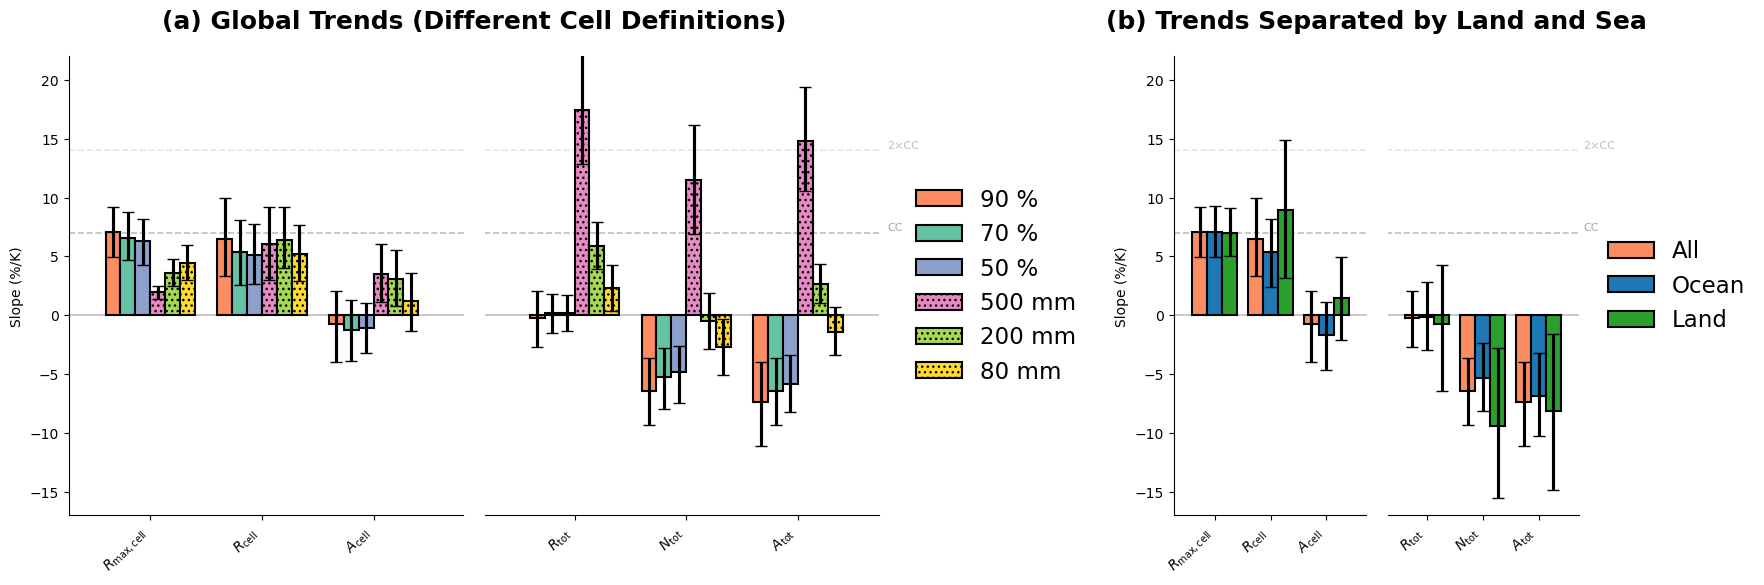

In [6]:
fig = plt.figure(figsize=(18, 6))
gs = gridspec.GridSpec(1, 2, width_ratios=[2, 1], figure=fig)

axes = [fig.add_subplot(gs[0]), fig.add_subplot(gs[1])]

plotting.plot_slope_comparison(
    ds=ds,
    variable_order=variable_order,
    variant_order=variant_order,
    VAR_META=VAR_META,
    hatches=hatches,
    colors = colors,
    ylabel='Slope (%/K)',
    ylim=(-17, 22),
    title=f'{int(ds.year_min[0][0].values)}-{int(ds.year_max[0][0].values)}',
    ax_passed=axes[0],         
)

plotting.plot_slope_comparison(
    ds=ds_sub,
    variable_order=['max_cell','tot_cell','area_cell','sum_tot','sum_counts','sum_area'],
    variant_order=['All','Ocean','Land'],
    VAR_META=VAR_META,
    colors=colors_surface,
    hatches=hatches_surface,
    ylabel='Slope (%/K)',
    title=name_experiment,
    ylim=(-17, 22),
    ax_passed=axes[1],          
)

axes[0].set_title('(a) Global Trends (Different Cell Definitions)', fontweight = 'bold', pad = 20)
axes[1].set_title('(b) Trends Separated by Land and Sea', fontweight = 'bold', pad = 20)


plt.show()